In [64]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
tqdm.pandas()

In [65]:
model_pred_col = "Camelbert-MSA"
# model_pred_col = "AraBert"

In [66]:
xai_exec = pd.read_csv("data/xai_exec/xai_exec_" + model_pred_col + ".csv")

In [67]:
xai_exec = xai_exec[["LIME", "SHAP", "IG", "DeepLIFT"]]

In [68]:
xai_exec["LIME"] = xai_exec["LIME"].apply(lambda x: np.array(eval(x))[:, 2].astype(float))
xai_exec["SHAP"] = xai_exec["SHAP"].apply(lambda x: np.array(eval(x))[:, 2].astype(float))
xai_exec["IG"] = xai_exec["IG"].apply(lambda x: np.array(eval(x))[:, 2].astype(float))
xai_exec["DeepLIFT"] = xai_exec["DeepLIFT"].apply(lambda x: np.array(eval(x))[:, 2].astype(float))

In [69]:
corr_dict = {
    "LIME": {"SHAP": [], "IG": [], "DeepLIFT": []},
    "SHAP": {"LIME": [], "IG": [], "DeepLIFT": []},
    "IG": {"LIME": [], "SHAP": [], "DeepLIFT": []},
    "DeepLIFT": {"LIME": [], "SHAP": [], "IG": []}
}

In [70]:
# loop through each row in the dataframe
for index, row in tqdm(xai_exec.iterrows(), total=xai_exec.shape[0]):
    # loop through each pair of methods
    for method1 in corr_dict.keys():
        for method2 in corr_dict[method1].keys():
            # calculate the correlation between the two methods for this row
            corr = np.corrcoef(row[method1], row[method2])[0, 1]
            # append the correlation to the list for this pair of methods
            corr_dict[method1][method2].append(corr)

  0%|          | 0/3033 [00:00<?, ?it/s]

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [75]:
# avg
avg_corr_dict = {}
for method1 in corr_dict.keys():
    avg_corr_dict[method1] = {}
    for method2 in corr_dict[method1].keys():
        avg_corr_dict[method1][method2] = np.nanmean(corr_dict[method1][method2])

In [79]:
# convert corr_dict to a dataframe
avg_corr_df = pd.DataFrame(avg_corr_dict)
avg_corr_df.fillna(1, inplace=True)

,LIME,SHAP,IG,DeepLIFT
SHAP,0.432835,1.000000,0.175326,0.025620
IG,0.216091,0.175326,1.000000,0.270390
DeepLIFT,0.006957,0.025620,0.270390,1.000000
LIME,1.000000,0.432835,0.216091,0.006957


In [80]:
# use the same order of methods in index and cols
avg_corr_df = avg_corr_df.reindex(index=["LIME", "SHAP", "IG", "DeepLIFT"], columns=["LIME", "SHAP", "IG", "DeepLIFT"])
avg_corr_df

,LIME,SHAP,IG,DeepLIFT
LIME,1.000000,0.432835,0.216091,0.006957
SHAP,0.432835,1.000000,0.175326,0.025620
IG,0.216091,0.175326,1.000000,0.270390
DeepLIFT,0.006957,0.025620,0.270390,1.000000


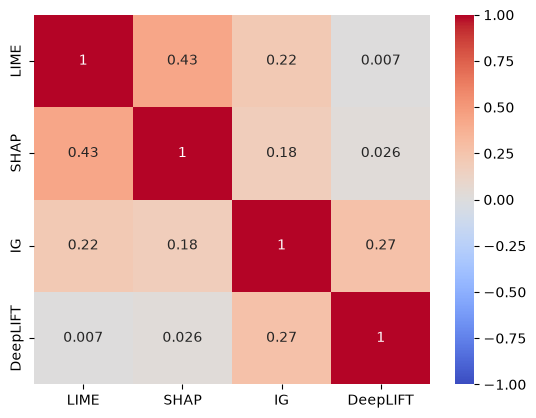

In [82]:
# convert to seaborn heatmap
import seaborn as sns
from matplotlib import pyplot as plt

sns.heatmap(avg_corr_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()